# **ICU DB Merged - Modeling with Class Weight Balanced**
------------------------------------
**Goal:** make a model that is optimized, regardless of realistic situations and see how that performs and what that means

### Summary: 
- Loaded preprocessed ICU dataset (mortality outcome).
- Split data into 70/15/15 train/validation/test sets.
- Trained Random Forest (class_weight='balanced') and XGBoost (scale_pos_weight) models.
- Tuned probability thresholds using balanced F1 on validation set.
- Evaluated both models on the test set using their tuned thresholds.
- Generated feature importance for RF and XGB.
- Performed quick fairness analysis across: Gender, Ethnicity, and ICU Unit Type
- Visualized fairness metrics with barplots (recall, precision, F1)

### Key Findings
Overall - The class weight balanced models produce stable, moderately balanced recall & precision, with no clear model driven bias, and feature importance aligns with real clinical severity markers.

- Model Performance
    - Both RF and XGB achieved similar F1 scores (0.40–0.47) for the positive (mortality) class
    - XGB had slightly higher precision, RF had slightly higher recall
    - Balanced thresholds resulted in fewer false negatives, which is good for mortality detection


- Feature Perfomance
    - RF top features: APACHE score, albumin, BUN, resp rate, creatinine
    - XGB top features: vent_day1, apache score, activetx, admission height, heart rate max
    - Both models rely heavily on acuity / severity indicators, clinically meaningful



- Fairness Results
    - No major systematic bias observed
    - Most variation in recall/precision comes from tiny subgroup sample sizes, especially: Small ethnic minorities and small unit types (CTICU, SICU, Neuro ICU)
    - Larger groups (Male vs Female, Med-Surg ICU, Caucasian) were fairly consistent across model


--------

In [1]:
# import/libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.metrics import precision_score, recall_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
target_col = "bad_outcome"

# load preprocessed data
df = pd.read_csv("ICUop_prep.csv")

print("Shape:", df.shape)

print("\nDtypes summary:\n", df.dtypes.value_counts())

print("\nAll columns & dtypes:\n")
display(df.dtypes.to_frame("dtype"))

print("\nTarget distribution:\n", df[target_col].value_counts(normalize=True))

print("\nTotal NaNs:", df.isna().sum().sum())

Shape: (2520, 127)

Dtypes summary:
 float64    118
object       8
int64        1
Name: count, dtype: int64

All columns & dtypes:



,dtype
gender,object
ethnicity,object
hospitalid,float64
unittype,object
admissionheight,float64
...,...
heartrate_max_log,float64
heartrate_std_log,float64
respiration_mean_log,float64
respiration_max_log,float64



Target distribution:
 bad_outcome
0    0.88373
1    0.11627
Name: proportion, dtype: float64

Total NaNs: 0


In [5]:
pd.set_option("display.max_rows", None)
display(df.dtypes.to_frame("dtype"))

,dtype
gender,object
ethnicity,object
hospitalid,float64
unittype,object
admissionheight,float64
admissionweight,float64
dischargeweight,float64
unitadmitsource,object
hospitaladmitsource,object
numbedscategory,object


In [7]:
# looking at cols and what to drop

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numeric cols:", len(num_cols))
print("\n\nCategorical cols:", len(cat_cols))
print("\n\nCategorical:", cat_cols)

Numeric cols: 118


Categorical cols: 8


Categorical: ['gender', 'ethnicity', 'unittype', 'unitadmitsource', 'hospitaladmitsource', 'numbedscategory', 'teachingstatus', 'region']


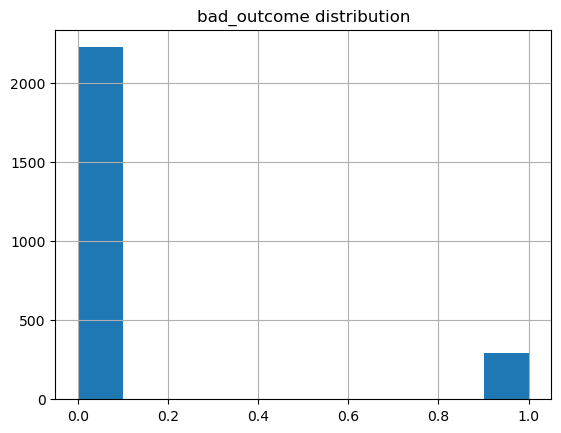

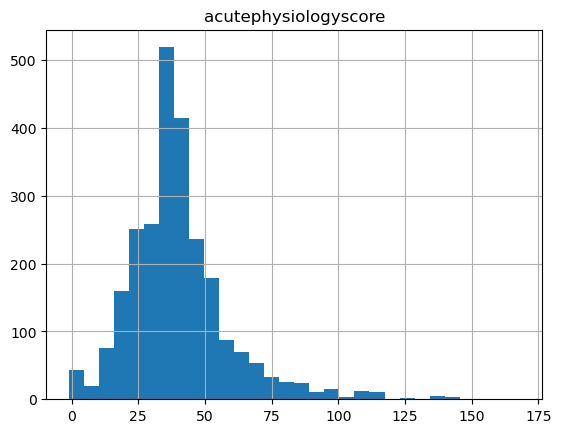

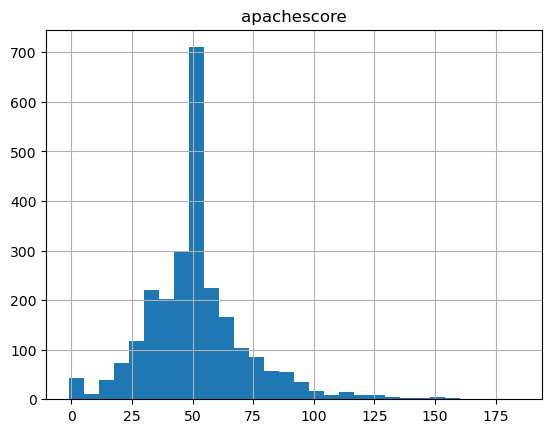

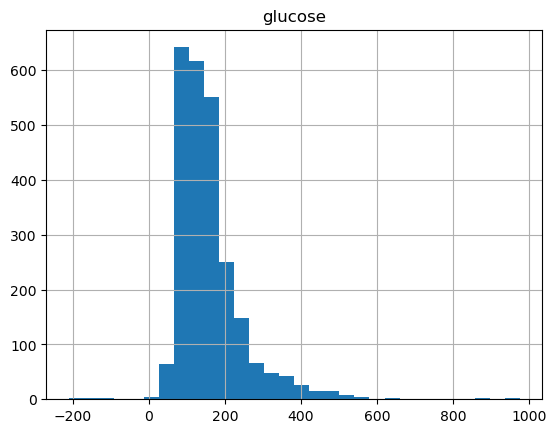

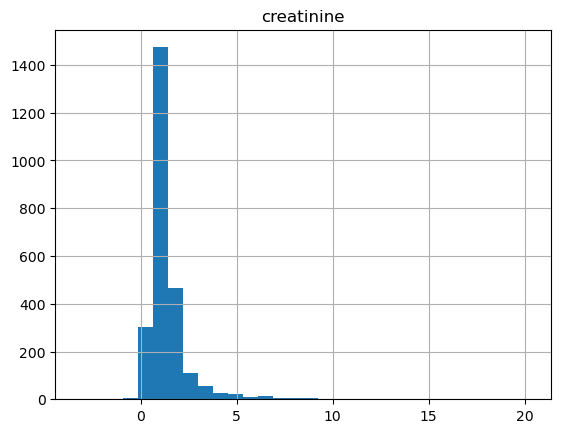

In [9]:
# quick distributions (just target and a few key features)
df[target_col].hist()
plt.title("bad_outcome distribution")
plt.show()

for col in ["acutephysiologyscore", "apachescore", "glucose", "creatinine"]:
    if col in df.columns:
        df[col].hist(bins=30)
        plt.title(col)
        plt.show()

In [11]:
# droppging acutephysiologyscore and only keeping apachescore
# APACHE score already includes the Acute Physiology Score 
# in the eICU database: apachescore = APACHE IVa score (final composite score) and acutephysiologyscore = APS component of APACHE
# highly correlated, and using both double-counts the same physiology information

df = df.drop(columns=["acutephysiologyscore"], errors="ignore")

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

print("Updated numeric cols:", len(num_cols))

Updated numeric cols: 117


In [13]:
# doing this to drop obviously useless/low-variance features

low_var_cols = []
for col in num_cols:
    if df[col].nunique() <= 1:
        low_var_cols.append(col)

print("Constant numeric cols:", low_var_cols)

Constant numeric cols: ['aids']


In [15]:
# also force-drop aids if still present
if "aids" in df.columns and "aids" not in low_var_cols:
    low_var_cols.append("aids")

print("Dropping:", low_var_cols)
df = df.drop(columns=low_var_cols)

# update num_cols
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]
print("Numeric cols after drop:", len(num_cols))

Dropping: ['aids']
Numeric cols after drop: 116


In [17]:
# making fairness columns and one-hot encode categoricals

# columns we will use later for subgroup fairness analysis
fairness_cols = ["gender", "ethnicity", "unittype"]

# keeping this separate for later merging w/ predictions
fair_df = df[fairness_cols + [target_col]].copy()

# one hot encode categorical columns for modeling
df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Shape after get_dummies:", df_model.shape)

# X and y
X = df_model.drop(columns=[target_col])
y = df_model[target_col].astype(int)

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True))

Shape after get_dummies: (2520, 156)
X shape: (2520, 155)
y distribution:
 bad_outcome
0    0.88373
1    0.11627
Name: proportion, dtype: float64


-------
## **Split the Data 70/15/15**

In [20]:
# 70% of data: training 
# 15% of data: validation (pick thresholds / compare models)
# 15% of data: test (final unbiased performance)
# carry along fair_df so we can do fairness analysis later

# 1st split: TRAIN (70%) vs TEMP (30%)
X_train, X_temp, y_train, y_temp, fair_train, fair_temp = train_test_split(
    X,            
    y,           
    fair_df, # fairness cols (gender, ethnicity, unittype, bad_outcome)
    test_size=0.30, # 30% goes into TEMP, 70% stays in TRAIN
    random_state=42,     
    stratify=y # keep same class balance as og
)

# 2nd split: TEMP (30%), VAL (15%) & TEST (15%)
# split TEMP in half: 0.15 val & 0.15 test out of the original 1.0
X_val, X_test, y_val, y_test, fair_val, fair_test = train_test_split(
    X_temp,
    y_temp,
    fair_temp,
    test_size=0.50, # half of TEMP is TEST, other half is VAL
    random_state=42,
    stratify=y_temp # keep positive rate similar across VAL/TEST
)

# check: shapes & positive rate (mean of y)
print("Train:", X_train.shape, "pos rate:", y_train.mean())
print("Val:  ", X_val.shape,   "pos rate:", y_val.mean())
print("Test: ", X_test.shape,  "pos rate:", y_test.mean())

Train: (1764, 155) pos rate: 0.11621315192743764
Val:   (378, 155) pos rate: 0.1164021164021164
Test:  (378, 155) pos rate: 0.1164021164021164


## **Standardizing Features (Z-score)**

In [23]:
# fit scaler on TRAIN only ( no leak info from val/test)
# transform train, val, test w/ that scaler
# using the scaled versions for SMOTE + modeling

scaler = StandardScaler()

# fit on TRAIN features only
scaler.fit(X_train)

# transform ea split
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# check
print("scaled shapes:")
print("train:", X_train_scaled.shape)
print("\nval:  ", X_val_scaled.shape)
print("\ntest: ", X_test_scaled.shape)

scaled shapes:
train: (1764, 155)

val:   (378, 155)

test:  (378, 155)


-----------------

## **Train Random Forest**

In [26]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

rf_val_proba  = rf.predict_proba(X_val_scaled)[:, 1]
rf_test_proba = rf.predict_proba(X_test_scaled)[:, 1]

print("RF AUC VAL:", roc_auc_score(y_val, rf_val_proba))
print("RF AUC TEST:", roc_auc_score(y_test, rf_test_proba))

RF AUC VAL: 0.7809608056614045
RF AUC TEST: 0.865405552531301


## **Train XGBoost**

In [29]:
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / pos

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=spw,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_scaled, y_train)

xgb_val_proba  = xgb.predict_proba(X_val_scaled)[:,1]
xgb_test_proba = xgb.predict_proba(X_test_scaled)[:,1]

print("XGB AUC VAL:",  roc_auc_score(y_val, xgb_val_proba))
print("XGB AUC TEST:", roc_auc_score(y_test, xgb_test_proba))

XGB AUC VAL: 0.7921883505715841
XGB AUC TEST: 0.850707675557975


---------
## **Threshold Tuning (Balanced F1, tie-break by recall)**



In [32]:
# sweep thresholds from 0.01 to 0.99 and compute recall, precision, F1.
# returns array with columns: [thr, recall, precision, f1]
def sweep_thresholds(y_true, y_proba, n_points=99):
    thresholds = np.linspace(0.01, 0.99, n_points)
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        rows.append((t, rec, prec, f1))
    return np.array(rows)


# picks 'balanced' threshold: maximizes f1 if F1 is within ~0.01 of best, pick higher recall
def choose_threshold_balance(y_true, y_proba):
    metrics = sweep_thresholds(y_true, y_proba)
    thrs = metrics[:, 0]
    recs = metrics[:, 1]
    precs = metrics[:, 2]
    f1s = metrics[:, 3]

    best_idx = 0
    for i in range(1, len(thrs)):
        better_f1 = f1s[i] > f1s[best_idx]
        similar_f1 = np.isclose(f1s[i], f1s[best_idx], atol=0.01)
        better_recall = recs[i] > recs[best_idx]

        if better_f1 or (similar_f1 and better_recall):
            best_idx = i

    best = {
        "thr": float(thrs[best_idx]),
        "recall": float(recs[best_idx]),
        "precision": float(precs[best_idx]),
        "f1": float(f1s[best_idx]),
    }
    return best, metrics


def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(cm)

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, int(v), ha="center", va="center")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()

RF best balanced threshold: {'thr': 0.25, 'recall': 0.5, 'precision': 0.34375, 'f1': 0.4074074074074074}

RF validation report (balanced threshold):
              precision    recall  f1-score   support

           0      0.930     0.874     0.901       334
           1      0.344     0.500     0.407        44

    accuracy                          0.831       378
   macro avg      0.637     0.687     0.654       378
weighted avg      0.862     0.831     0.844       378



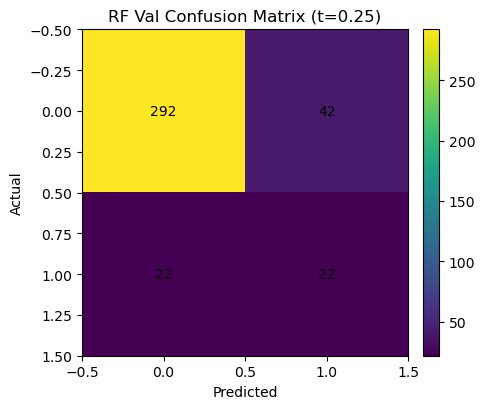

In [34]:
# run tuning for RF (balanced-weight)
rf_best, rf_metrics = choose_threshold_balance(y_val.values, rf_val_proba)
print("RF best balanced threshold:", rf_best)

rf_val_pred_best = (rf_val_proba >= rf_best["thr"]).astype(int)

print("\nRF validation report (balanced threshold):")
print(classification_report(y_val, rf_val_pred_best, digits=3))
plot_confusion(y_val, rf_val_pred_best,
               title=f"RF Val Confusion Matrix (t={rf_best['thr']:.2f})")


XGB best balanced threshold: {'thr': 0.36000000000000004, 'recall': 0.4772727272727273, 'precision': 0.3559322033898305, 'f1': 0.4077669902912621}

XGB validation report (balanced threshold):
              precision    recall  f1-score   support

           0      0.928     0.886     0.907       334
           1      0.356     0.477     0.408        44

    accuracy                          0.839       378
   macro avg      0.642     0.682     0.657       378
weighted avg      0.861     0.839     0.849       378



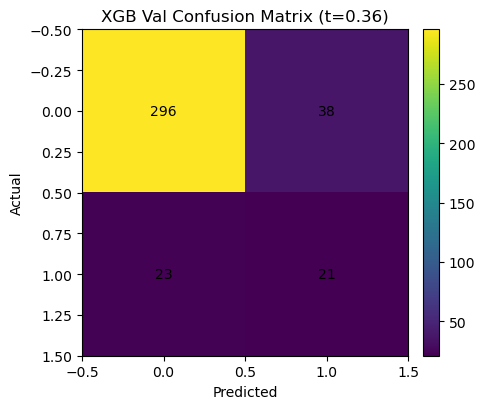

In [36]:
# run tuning for XGB (balanced-weight)
xgb_best, xgb_metrics = choose_threshold_balance(y_val.values, xgb_val_proba)
print("\nXGB best balanced threshold:", xgb_best)

xgb_val_pred_best = (xgb_val_proba >= xgb_best["thr"]).astype(int)

print("\nXGB validation report (balanced threshold):")
print(classification_report(y_val, xgb_val_pred_best, digits=3))
plot_confusion(y_val, xgb_val_pred_best,
               title=f"XGB Val Confusion Matrix (t={xgb_best['thr']:.2f})")


RF TEST report (balanced threshold):
              precision    recall  f1-score   support

           0      0.939     0.883     0.910       334
           1      0.391     0.568     0.463        44

    accuracy                          0.847       378
   macro avg      0.665     0.726     0.687       378
weighted avg      0.876     0.847     0.858       378



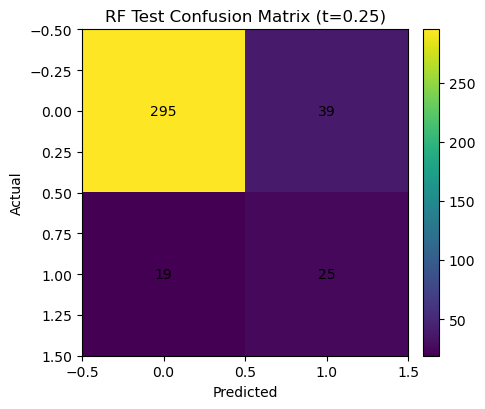


XGB TEST report (balanced threshold):
              precision    recall  f1-score   support

           0      0.931     0.928     0.930       334
           1      0.467     0.477     0.472        44

    accuracy                          0.876       378
   macro avg      0.699     0.703     0.701       378
weighted avg      0.877     0.876     0.876       378



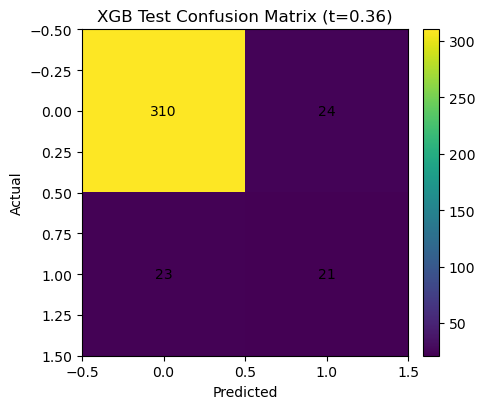

In [38]:
# evaluate BOTH on TEST using their tuned thresholds

# RF on test
rf_test_pred_best = (rf_test_proba >= rf_best["thr"]).astype(int)
print("\nRF TEST report (balanced threshold):")
print(classification_report(y_test, rf_test_pred_best, digits=3))
plot_confusion(y_test, rf_test_pred_best,
               title=f"RF Test Confusion Matrix (t={rf_best['thr']:.2f})")

# XGB on test
xgb_test_pred_best = (xgb_test_proba >= xgb_best["thr"]).astype(int)
print("\nXGB TEST report (balanced threshold):")
print(classification_report(y_test, xgb_test_pred_best, digits=3))
plot_confusion(y_test, xgb_test_pred_best,
               title=f"XGB Test Confusion Matrix (t={xgb_best['thr']:.2f})")

**Notes:**

**Random Forest**

Overall: more recall heavy, catches more risky cases, decent f1 but perscision is low

Validation (t=0.25)
- recall (positive) = 0.5
- precision (positive) = 0.34
- f1 = 0.41
- pattern: rf still manages to catch half of the sick patients (22/44) and still has 42 falase postives, pretty balanced? leans on recall

Test (t=0.25) 
- recall (positive) = 0.57
- precision (positive) = 0.39
- f1 = 0.46
- pattern: performace improve slightly, rf more sensitive on the test set here. Still has a moderate false positive but cathes more true sick patients than XGB


**XGBoost**

Overall: most balanced model better. better percision than RF but slightly lower recall, best f1 on test set (0.47). cleanest confusion matrix 

Validation (t=0.36)
- recall (positive) = 0.48
- precision (positive) = 0.36
- f1 = 0.41
- pattern: almost identical to the RF, slight cleaner predictions


Test (t=0.36) 
- recall (positive) = 0.48
- precision (positive) = 0.47
- f1 = 0.47
- pattern: very balanced performance, catches half of the sick patients but also mislabels fewer healthy ones 


--------
## **Feature Importance**


Top 20 RF features:


,feature,importance
4,apachescore,0.028818
49,apachescore_w,0.027140
61,albumin_w,0.021584
16,albumin,0.019583
101,albumin_log,0.019143
13,bun,0.018090
58,bun_w,0.017558
98,bun_log,0.017302
48,acutephysiologyscore_w,0.015275
85,respiration_mean_w,0.012949


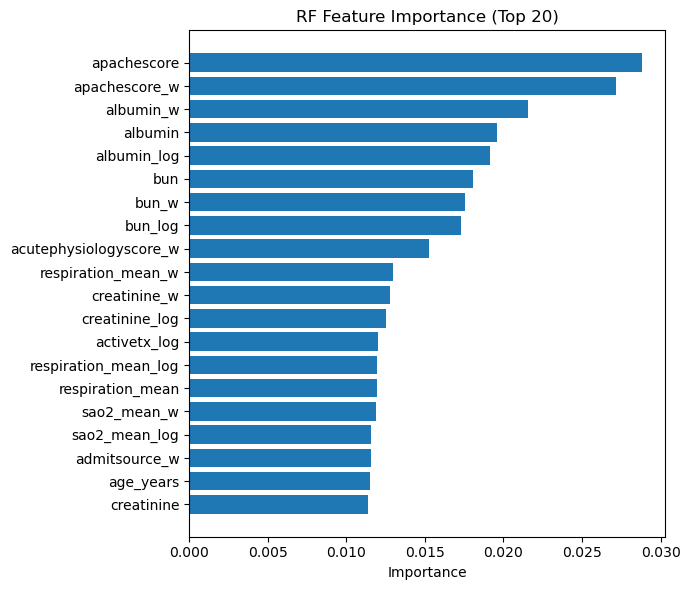

In [41]:
# RF feature importance
rf_model = None
if "rf_bw" in globals():
    rf_model = rf_bw
elif "rf" in globals():
    rf_model = rf

if rf_model is None:
    print("\n[Feature Importance] Couldn't find rf_bw or rf model in memory.")
else:
    rf_importances = rf_model.feature_importances_
    rf_features = X_train.columns # using the og (unscaled) feature names

    rf_imp_df = (
        pd.DataFrame({"feature": rf_features, "importance": rf_importances})
        .sort_values("importance", ascending=False)
    )

    print("\nTop 20 RF features:")
    display(rf_imp_df.head(20))

    # plot top 20
    topN = 20
    top_df = rf_imp_df.head(topN).iloc[::-1]  # reverse for barh ordering

    plt.figure(figsize=(7, 6))
    plt.barh(top_df["feature"], top_df["importance"])
    plt.title("RF Feature Importance (Top 20)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


Top 20 XGB features (gain):


,feature,gain_importance
105,ventday1_log,44.669003
49,apachescore_w,40.752506
76,activetx_w,32.503326
88,admissionheight_log,31.035637
32,activetx,28.897182
68,admitsource_w,27.355030
117,ethnicity_Unknown,26.563278
109,heartrate_max_log,23.038925
124,unitadmitsource_Floor,21.722624
50,intubated_w,21.542412


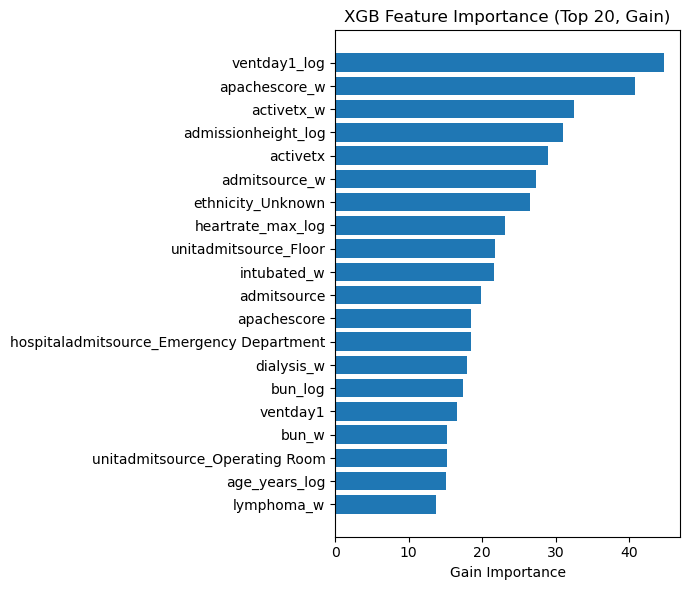

In [43]:
# XGB feature importance
xgb_model = None
if "xgb_bw" in globals():
    xgb_model = xgb_bw
elif "xgb" in globals():
    xgb_model = xgb

if xgb_model is None:
    print("\n[XGB Feature Importance] Couldn't find xgb_bw or xgb model in memory.")
else:
    try:
        booster = xgb_model.get_booster()
        score_dict = booster.get_score(importance_type="gain")

        # Map XGB's f0,f1,... back to real column names
        xgb_feat_map = {f"f{i}": col for i, col in enumerate(X_train.columns)}
        xgb_imp = [
            (xgb_feat_map.get(k, k), v) for k, v in score_dict.items()
        ]

        xgb_imp_df = (
            pd.DataFrame(xgb_imp, columns=["feature", "gain_importance"])
            .sort_values("gain_importance", ascending=False)
        )

        print("\nTop 20 XGB features (gain):")
        display(xgb_imp_df.head(20))

        topN = 20
        top_df = xgb_imp_df.head(topN).iloc[::-1]

        plt.figure(figsize=(7, 6))
        plt.barh(top_df["feature"], top_df["gain_importance"])
        plt.title("XGB Feature Importance (Top 20, Gain)")
        plt.xlabel("Gain Importance")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print("\n[XGB Feature Importance] Something went wrong:", e)

**notes:**

overall - RF focuses more on physiology, while XGB incorporates both severity and the early interventions, explaining the slight performance differences

**Random Forest**
- top features are all mostdyly core physiologic markers
    - apachescore, apachescore_w, strongest predictors
    - albumin, bun, creatinine and their _w / _log versions
    - respiration_mean / sao2_mean
    - activetx (treatment activity)
    - age_years
- relying mainly on severity indices, renal function, respiratory status, and age

**XGBoost**
- emphasizes interventions and early mechanical ventilation, plus admission source
- ventilation and APACHE dominate early mortality risk
- top features:
    - ventday1_log, ventday1, mechanical ventilation early in stay
    - apachescore_w, activetx_w → severity + treatments
    - admissionheight_log / admitresource_w
    - ethnicity_Unknown (inflated likely due to sparse one-hot categories)
    - heart rate max / bun / bun_w
    - unitadmitsource_Floor, OR, ED

---------

## **Quick Fairness Analysis**

In [81]:
def fairness_table(df_groups, group_col, y_true_s, y_pred_s):
    rows = []
    for g, sub in df_groups.groupby(group_col):
        yt = y_true_s.loc[sub.index]
        yp = y_pred_s.loc[sub.index]

        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()

        recall = tp / (tp + fn + 1e-9)
        precision = tp / (tp + fp + 1e-9)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

        rows.append({
            "group": g,
            "n": len(sub),
            "recall": recall,
            "precision": precision,
            "f1": f1,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })

    return pd.DataFrame(rows).sort_values("n", ascending=False)

In [83]:
fair_test = fair_df.loc[X_test.index].copy()

y_test_s  = pd.Series(y_test.values, index=X_test.index)

rf_pred_s  = pd.Series(rf_test_pred_best, index=X_test.index)
xgb_pred_s = pd.Series(xgb_test_pred_best, index=X_test.index)

group_cols = ["gender", "ethnicity", "unittype"]

In [85]:
group_cols = ["gender", "ethnicity", "unittype"]

print("FAIRNESS: RANDOM FOREST (TEST)")
for g in group_cols:
    print(f"\nBy {g.upper()}:")
    display(fairness_table(fair_test, g, y_test_s, rf_pred_s))


print("\n===========================")

print("FAIRNESS: XGBOOST (TEST)")
for g in group_cols:
    print(f"\nBy {g.upper()}:")
    display(fairness_table(fair_test, g, y_test_s, xgb_pred_s))

FAIRNESS: RANDOM FOREST (TEST)

By GENDER:


,group,n,recall,precision,f1,TP,FP,FN,TN
1,Male,252,0.560000,0.341463,0.424242,14,27,11,200
0,Female,126,0.578947,0.478261,0.523810,11,12,8,95



By ETHNICITY:


,group,n,recall,precision,f1,TP,FP,FN,TN
1,Caucasian,296,0.562500,0.375000,0.450000,18,30,14,234
0,African American,37,0.250000,0.166667,0.200000,1,5,3,28
2,Hispanic,22,1.000000,0.666667,0.800000,4,2,0,16
4,Other/Unknown,13,0.333333,0.333333,0.333333,1,2,2,8
3,Other,7,1.000000,1.000000,1.000000,1,0,0,6
5,Unknown,3,0.000000,0.000000,0.000000,0,0,0,3



By UNITTYPE:


...

,group,n,recall,precision,f1,TP,FP,FN,TN
1,Male,252,0.440000,0.407407,0.423077,11,16,14,211
0,Female,126,0.526316,0.555556,0.540541,10,8,9,99



By ETHNICITY:


,group,n,recall,precision,f1,TP,FP,FN,TN
1,Caucasian,296,0.5625,0.461538,0.507042,18,21,14,243
0,African American,37,0.0000,0.000000,0.000000,0,1,4,32
2,Hispanic,22,0.7500,1.000000,0.857143,3,0,1,18
4,Other/Unknown,13,0.0000,0.000000,0.000000,0,1,3,9
3,Other,7,0.0000,0.000000,0.000000,0,1,1,5
5,Unknown,3,0.0000,0.000000,0.000000,0,0,0,3



By UNITTYPE:


,group,n,recall,precision,f1,TP,FP,FN,TN
5,Med-Surg ICU,282,0.562500,0.5625,0.562500,18,14,14,236
4,MICU,22,0.500000,0.2000,0.285714,1,4,1,16
3,Cardiac ICU,20,0.666667,0.5000,0.571429,2,2,1,15
1,CSICU,17,0.000000,0.0000,0.000000,0,0,1,16
6,Neuro ICU,14,0.000000,0.0000,0.000000,0,1,4,9
7,SICU,12,0.000000,0.0000,0.000000,0,2,1,9
0,CCU-CTICU,7,0.000000,0.0000,0.000000,0,1,1,5
2,CTICU,4,0.000000,0.0000,0.000000,0,0,0,4


In [87]:
def compare_models_fairness_multi(df_rf, df_xgb, title, metrics=["recall","precision","f1"]):
    groups = df_rf["group"].astype(str).tolist()
    x = np.arange(len(groups))
    width = 0.35  # bar width

    fig, axes = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 4))

    if len(metrics) == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.bar(x - width/2, df_rf[metric], width, label='RF', color="darkorange")
        ax.bar(x + width/2, df_xgb[metric], width, label='XGB', color="steelblue")

        ax.set_title(f"{metric.title()} by Group")
        ax.set_xticks(x)
        ax.set_xticklabels(groups, rotation=45)
        ax.set_ylim(0, 1)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.legend()

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [89]:
rf_gender_fair     = fairness_table(fair_test, "gender",    y_test_s, rf_pred_s)
rf_ethnicity_fair  = fairness_table(fair_test, "ethnicity", y_test_s, rf_pred_s)
rf_unittype_fair   = fairness_table(fair_test, "unittype",  y_test_s, rf_pred_s)

xgb_gender_fair    = fairness_table(fair_test, "gender",    y_test_s, xgb_pred_s)
xgb_ethnicity_fair = fairness_table(fair_test, "ethnicity", y_test_s, xgb_pred_s)
xgb_unittype_fair  = fairness_table(fair_test, "unittype",  y_test_s, xgb_pred_s)

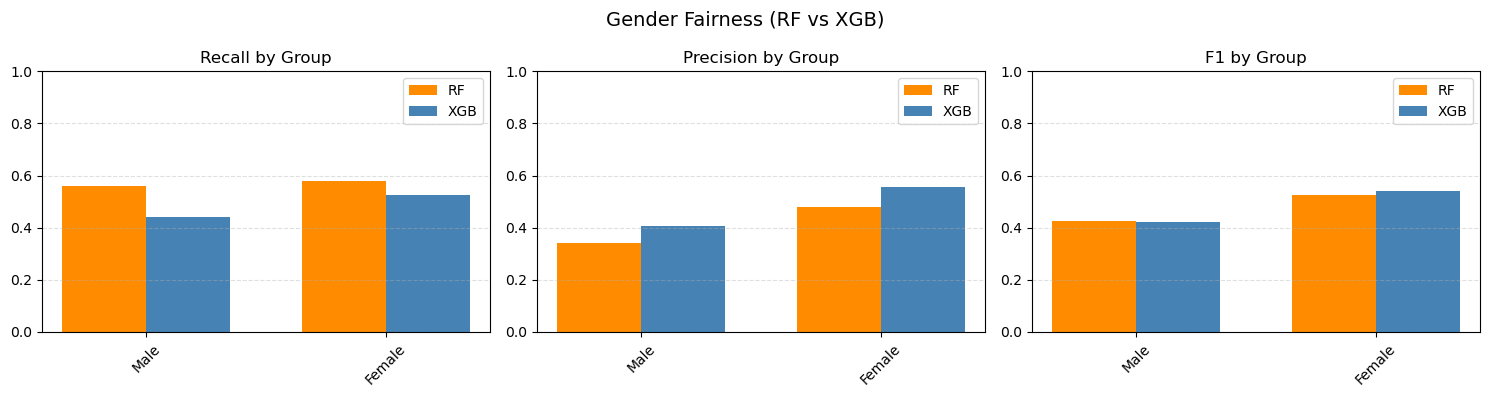

In [91]:
# gender
compare_models_fairness_multi(
    rf_gender_fair,
    xgb_gender_fair,
    "Gender Fairness (RF vs XGB)",
    metrics=["recall", "precision", "f1"]
)

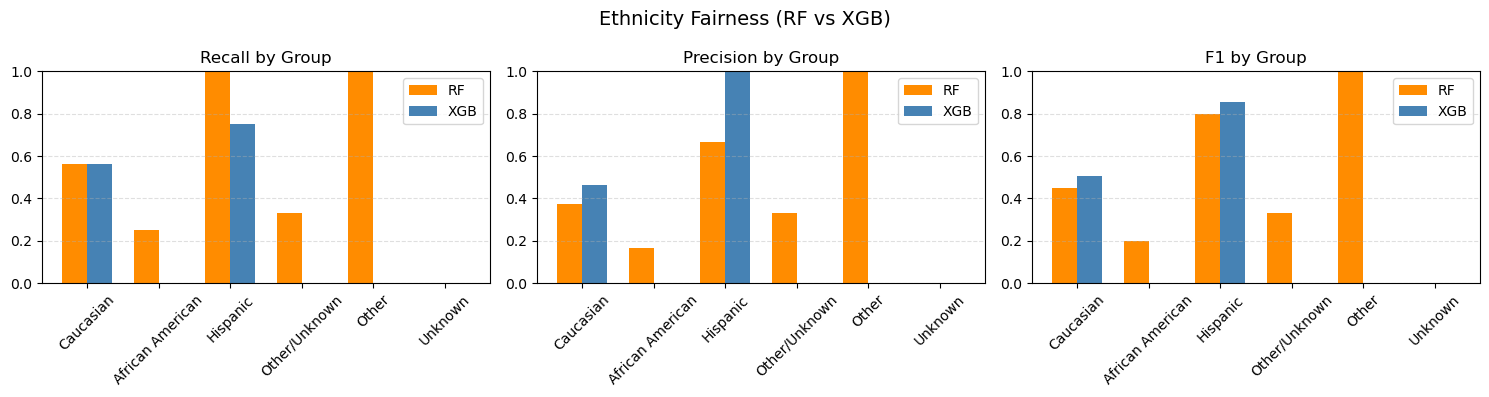

In [93]:
# ethnicity
compare_models_fairness_multi(
    rf_ethnicity_fair,
    xgb_ethnicity_fair,
    "Ethnicity Fairness (RF vs XGB)",
    metrics=["recall", "precision", "f1"]
)

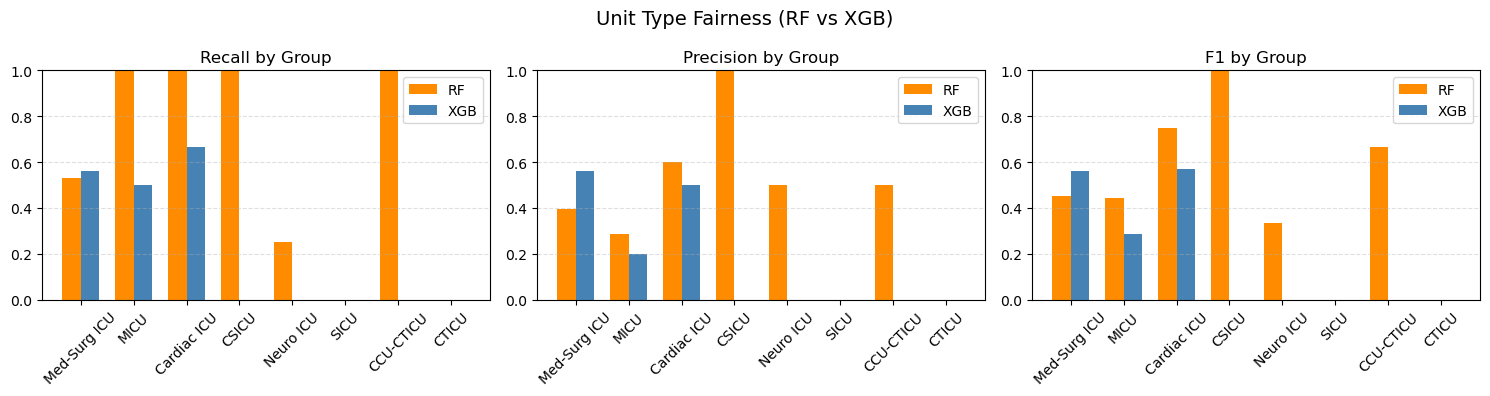

In [95]:
# unit type
compare_models_fairness_multi(
    rf_unittype_fair,
    xgb_unittype_fair,
    "Unit Type Fairness (RF vs XGB)",
    metrics=["recall", "precision", "f1"]
)

**notes:**

OVERALL: most fairness differences come from tiny subgroup sizes, not model bias
- Gender: Fairly balanced for RF; XGB favors females slightly
- Ethnicity: No consistent bias, sample sizes too small for most group
- unit type: Both models show instability in small ICUs, but RF is slightly more stable

**Gender Fainress**

RF
- Male: Recall 0.56, Precision 0.34, catches more positives but with more false positives
- Female: Recall 0.58, Precision 0.47, slightly better balance
- treats genders similarly, but Females get cleaner predictions

XGB
- Male: Recall 0.44, Precision 0.40 & Female: Recall 0.53, Precision 0.56
- favors females more clearly (higher recall and precision)

**Ethnicity Fairness**

RF
- No clear systemic bias, most variation is from very small sample sizes
- Caucasian group dominates sample with the recall = 0.56
- Small groups (African American, Hispanic, Other), the recall jumps around due to very small n
- Some ethnicities have perfect recall or 0 recall simply because their sample sizes are tiny (n=3–22)

XGB
- same pattern (caucasian recall is 0.56, other groups fluctuate heavily some groups get 0 recall because no positive cases were predicted (low sample sizes))
- inconclusive because the minority groups have extremely low counts

**ICU Unit Types**

RF
- Med-Surg ICU (big group): recall = 0.53
- Some tiny units (n=4–20) get recall = 0.0 or 1.0
- MICU, CCU-CTICU show better recall, but again small n
- does okay on the big unit types, but tiny ICUs swing

XGB
- Med-Surg ICU again stable around 0.56 recall
- Others vary heavily (0 to 1)
- More extreme drops than RF, especially in small ICUs
- slightly more unstable across unit types, especially for rare ICU categories
--------